In [3]:
!pip install kagglehub

# 2. Importowanie niezbędnych bibliotek
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Biblioteki zostały poprawnie zaimportowane!")

Biblioteki zostały poprawnie zaimportowane!


In [7]:
with open("/content/Streaming_History_Audio_2026.json", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

df = df[df["ms_played"] > 30000]
df["minutes_played"] = df["ms_played"] / 60000
df["ts"] = pd.to_datetime(df["ts"])
df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.day_name()

cols_to_keep = [
    "ts",
    "master_metadata_track_name",
    "master_metadata_album_artist_name",
    "spotify_track_uri",
    "minutes_played",
    "hour",
    "day_of_week",
]
df_clean = df[cols_to_keep].dropna()

df_clean["track_clean"] = (
    df_clean["master_metadata_track_name"].str.lower().str.strip()
)
df_clean["artist_clean"] = (
    df_clean["master_metadata_album_artist_name"].str.lower().str.strip()
)

print(
    f" Wyczyszczona historia Spotify zawiera {len(df_clean)} odtworzeń."
)

 Wyczyszczona historia Spotify zawiera 7310 odtworzeń.


In [5]:
import kagglehub

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

csv_file = os.path.join(path, "dataset.csv")
kaggle_df = pd.read_csv(csv_file)

kaggle_df["track_clean"] = kaggle_df["track_name"].astype(str).str.lower().str.strip()
kaggle_df["artist_clean"] = (
    kaggle_df["artists"].astype(str).str.lower().str.strip()
)
kaggle_df = kaggle_df.drop_duplicates(subset=["track_clean", "artist_clean"])

print(f"Baza z Kaggle zawiera {len(kaggle_df)} unikalnych utworów z cechami audio.")

100%|██████████| 8.17M/8.17M [00:00<00:00, 37.5MB/s]

Extracting files...


Baza z Kaggle zawiera 81207 unikalnych utworów z cechami audio.


In [8]:
features_cols = [
    "track_clean",
    "artist_clean",
    "track_genre",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]
kaggle_subset = kaggle_df[features_cols]

final_df = pd.merge(
    df_clean,
    kaggle_subset,
    on=["track_clean", "artist_clean"],
    how="inner",
)

print(
    f"Sukces! Udało się przypisać cechy audio dla {len(final_df)} Twoich odtworzeń."
)
final_df.head(3)

Sukces! Udało się przypisać cechy audio dla 1846 Twoich odtworzeń.


,ts,master_metadata_track_name,master_metadata_album_artist_name,spotify_track_uri,minutes_played,hour,day_of_week,track_clean,artist_clean,track_genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,2026-01-09 08:59:41+00:00,Bulls On Parade,Rage Against The Machine,spotify:track:0tZ3mElWcr74OOhKEiNz1x,3.82445,8,Friday,bulls on parade,rage against the machine,alt-rock,0.412,0.919,-7.291,0.1840,0.012400,0.060100,0.4240,0.572,166.367
1,2026-01-09 09:41:45+00:00,Free Bird,Lynyrd Skynyrd,spotify:track:5EWPGh7jbTNO2wakv8LjUI,9.11845,9,Friday,free bird,lynyrd skynyrd,blues,0.249,0.834,-8.210,0.0577,0.073800,0.000095,0.0924,0.338,118.223
2,2026-01-09 09:46:01+00:00,Rock You Like a Hurricane - 2011,Scorpions,spotify:track:46QazXxQS0B31CnbRCy8CV,4.25955,9,Friday,rock you like a hurricane - 2011,scorpions,german,0.587,0.891,-3.381,0.0361,0.000261,0.004540,0.3140,0.705,124.005


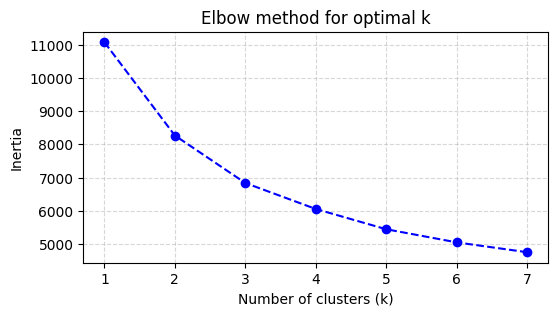

--- AVERAGE FEATURE VALUES PER CLUSTER ---
              danceability  energy  valence   tempo  acousticness  loudness
mood_cluster                                                               
0                     0.54    0.43     0.45  113.23          0.34    -12.28
1                     0.65    0.76     0.71  121.97          0.09     -6.90
2                     0.42    0.76     0.30  114.51          0.06     -6.40


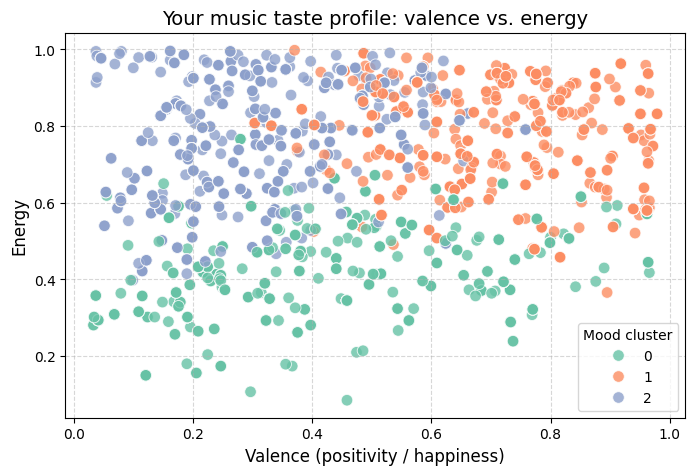

In [12]:
ml_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "acousticness",
    "loudness",
]
final_df = final_df.dropna(subset=ml_features).copy()

X = final_df[ml_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(K_range, inertia, "bo--")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method for optimal k")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

k_means = KMeans(n_clusters=3, n_init=10, random_state=42)
final_df["mood_cluster"] = k_means.fit_predict(X_scaled)

print("--- AVERAGE FEATURE VALUES PER CLUSTER ---")
cluster_profile = final_df.groupby("mood_cluster")[ml_features].mean().round(2)
print(cluster_profile)


plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=final_df,
    x="valence",
    y="energy",
    hue="mood_cluster",
    palette="Set2",
    s=70,
    alpha=0.8,
)

plt.title("Your music taste profile: valence vs. energy", fontsize=14)
plt.xlabel("Valence (positivity / happiness)", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Mood cluster")
plt.show()